In [1]:
# INF2190 Project - Decision Tree Analysis for Heart Dataset
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

In [2]:
# 2. Load the dataset

# Make sure the CSV file is in the same folder as this notebook
file = 'Heart Attack Data Set.csv'

df = pd.read_csv(file)

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['target'].value_counts())

First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset shape:
(303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca

In [3]:
# 3. Remove outliers using IQR
# Only apply outlier removal to continuous variables

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df_no_outliers = df.copy()

for col in continuous_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower_bound) &
        (df_no_outliers[col] <= upper_bound)
    ]

print("\nOriginal dataset shape:", df.shape)
print("Dataset shape after removing outliers:", df_no_outliers.shape)


Original dataset shape: (303, 14)
Dataset shape after removing outliers: (284, 14)


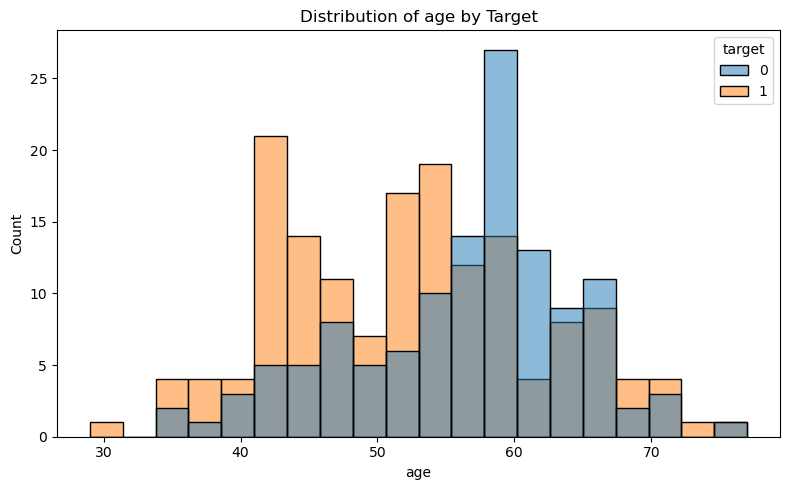

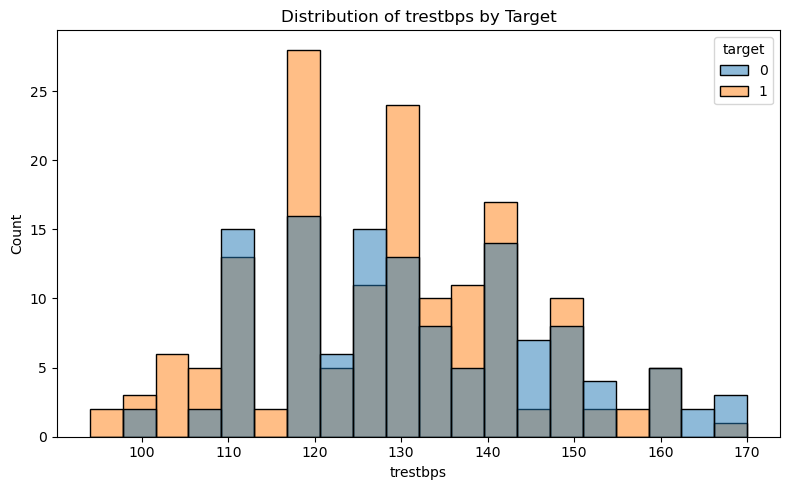

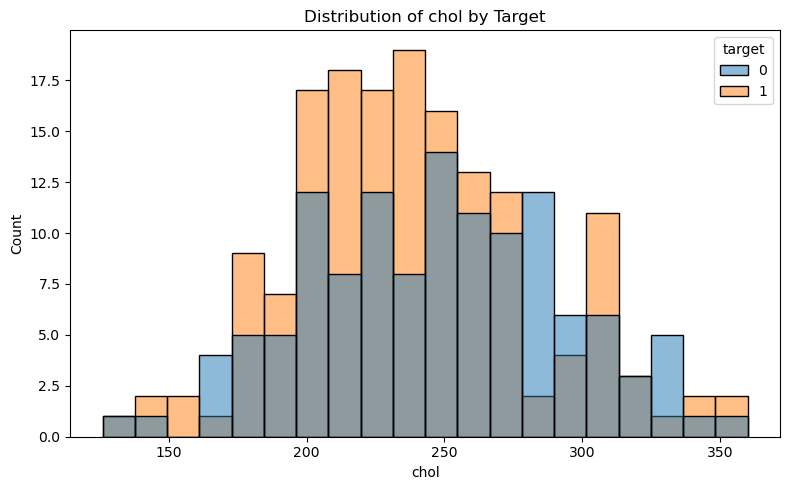

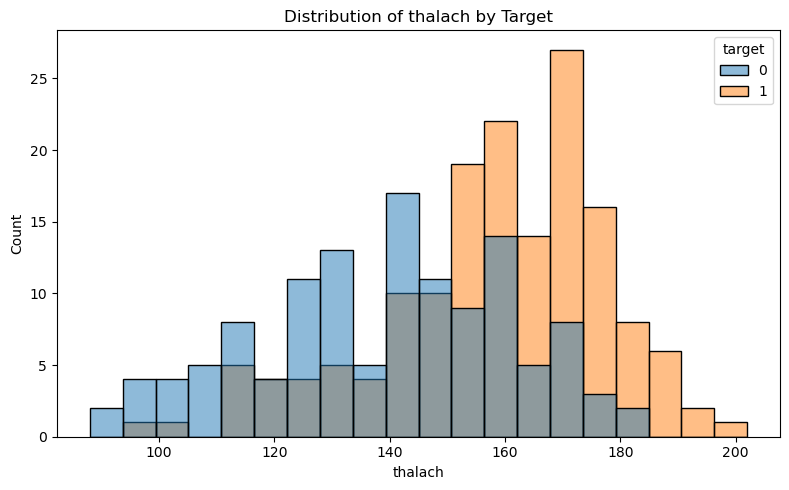

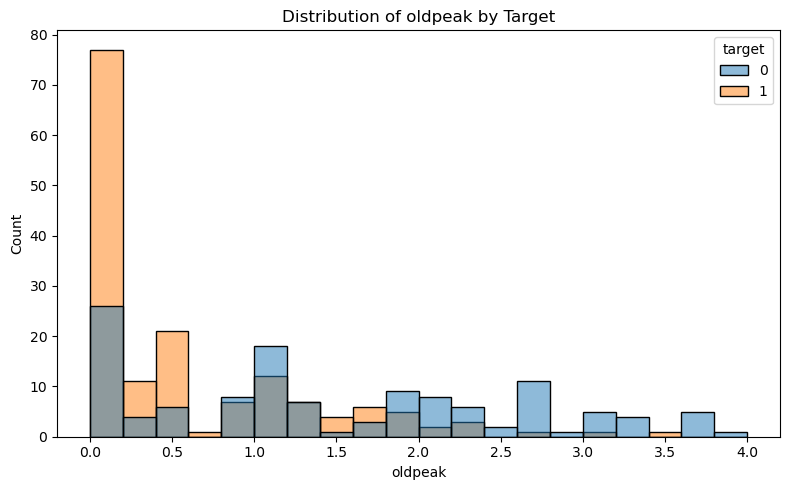

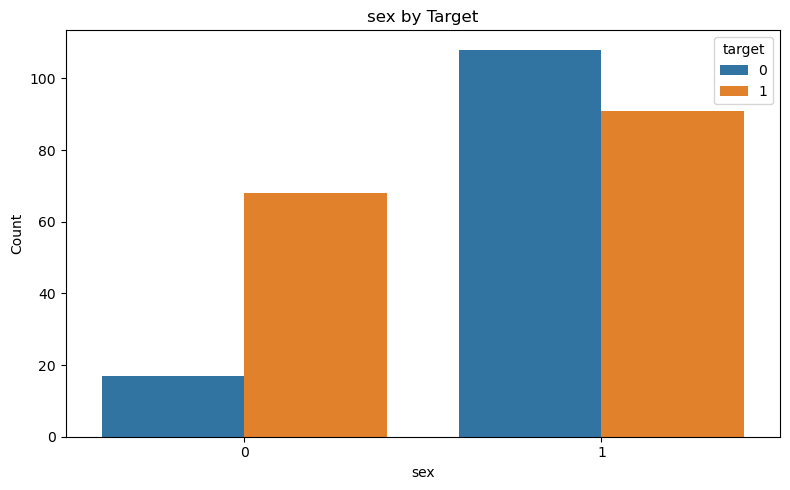

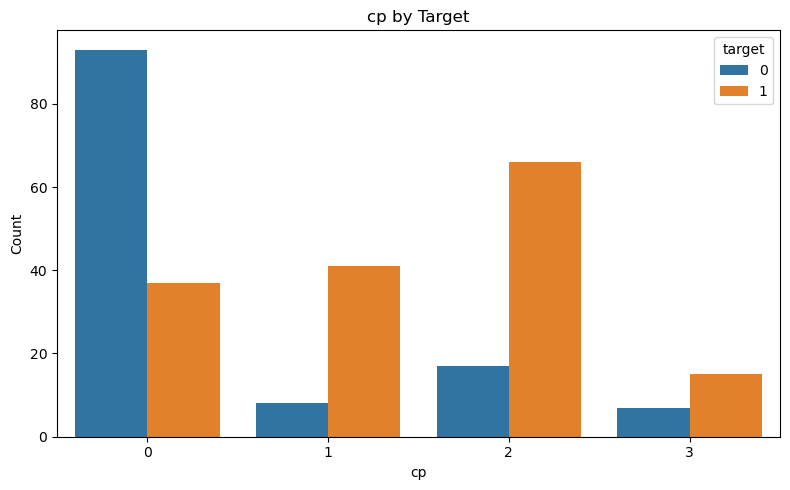

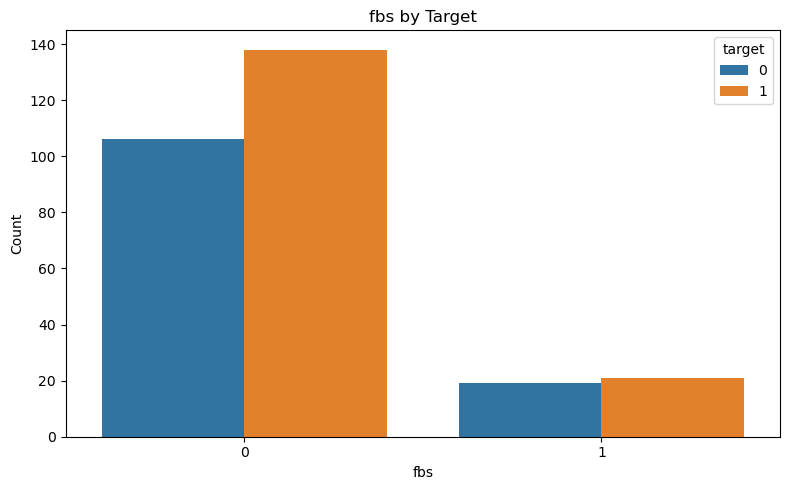

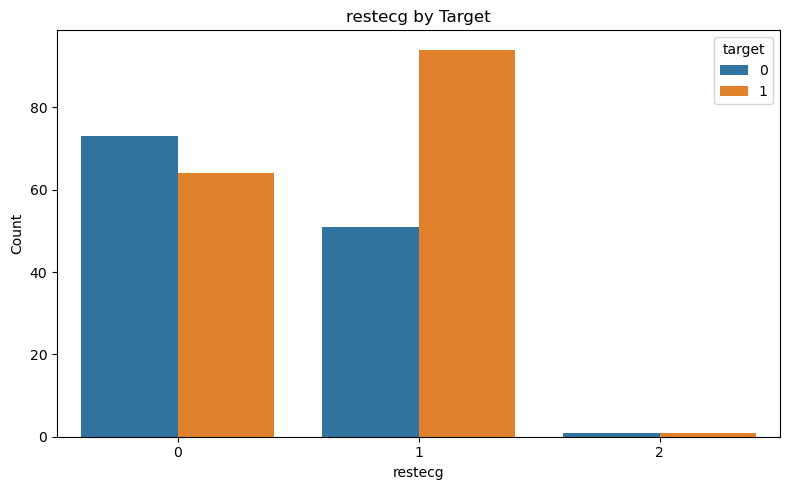

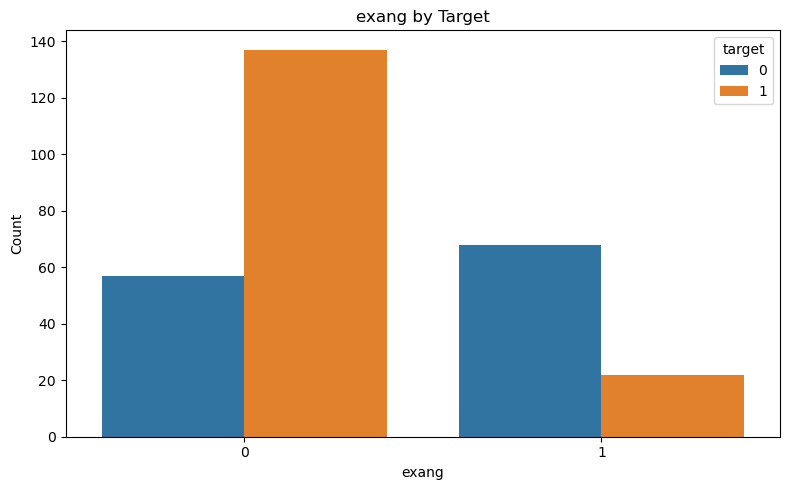

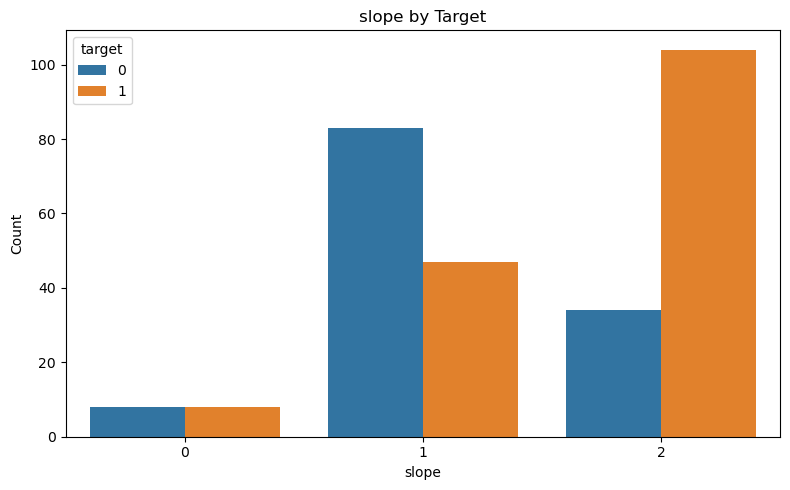

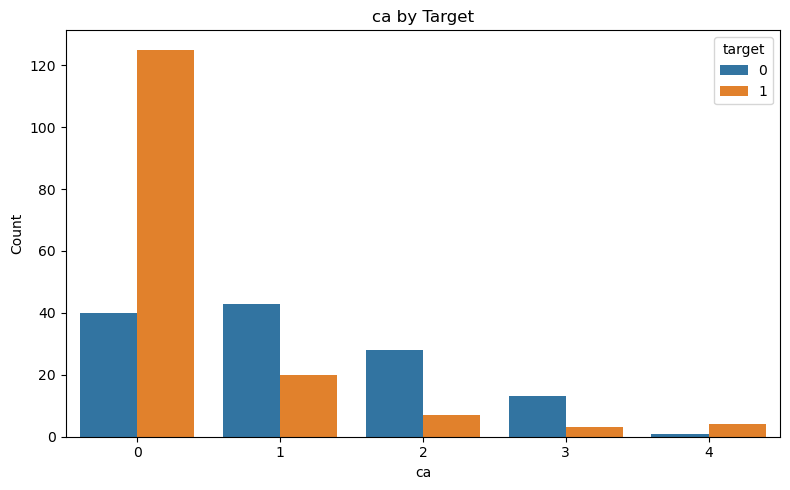

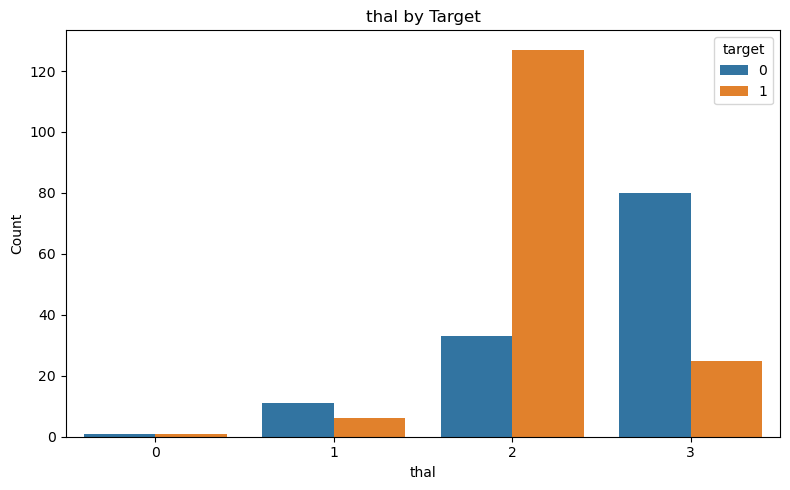

In [7]:
# 4. Exploratory analysis for each variable

import seaborn as sns

eda_df = df_no_outliers.copy()

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


# 4A. Continuous variables

for col in continuous_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=eda_df, x=col, hue='target', bins=20)
    plt.title(f'Distribution of {col} by Target')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# 4B. Categorical variables

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=eda_df, x=col, hue='target')
    plt.title(f'{col} by Target')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [8]:
# 5. Define features and target
# Remove fbs, chol, trestbps

X = df_no_outliers.drop(['target', 'fbs', 'chol', 'trestbps'], axis=1)
y = df_no_outliers['target']

# 6. Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (198, 10)
Testing set size: (86, 10)


Basic Decision Tree Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.76        36
           1       0.88      0.70      0.78        50

    accuracy                           0.77        86
   macro avg       0.77      0.78      0.77        86
weighted avg       0.79      0.77      0.77        86


Accuracy for different tree depths:
Depth: 2, Accuracy: 0.78
Depth: 3, Accuracy: 0.80
Depth: 4, Accuracy: 0.77
Depth: 5, Accuracy: 0.73
Depth: None, Accuracy: 0.77


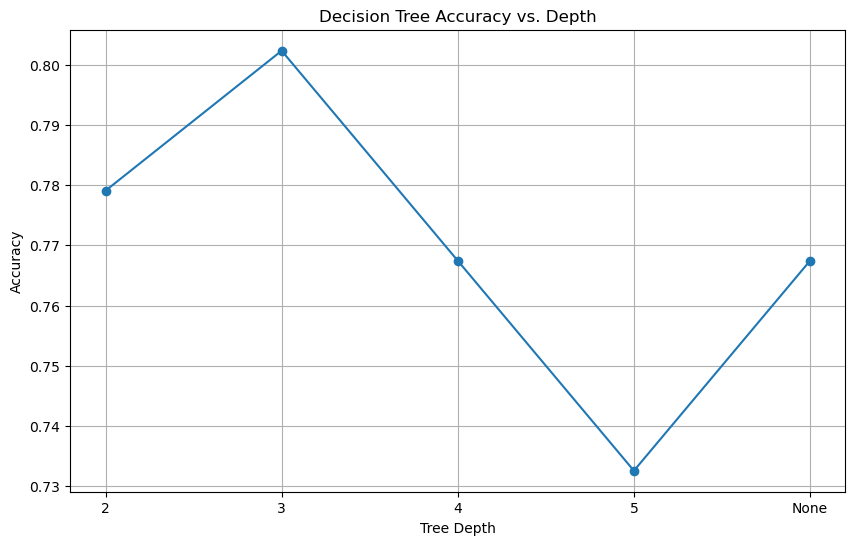

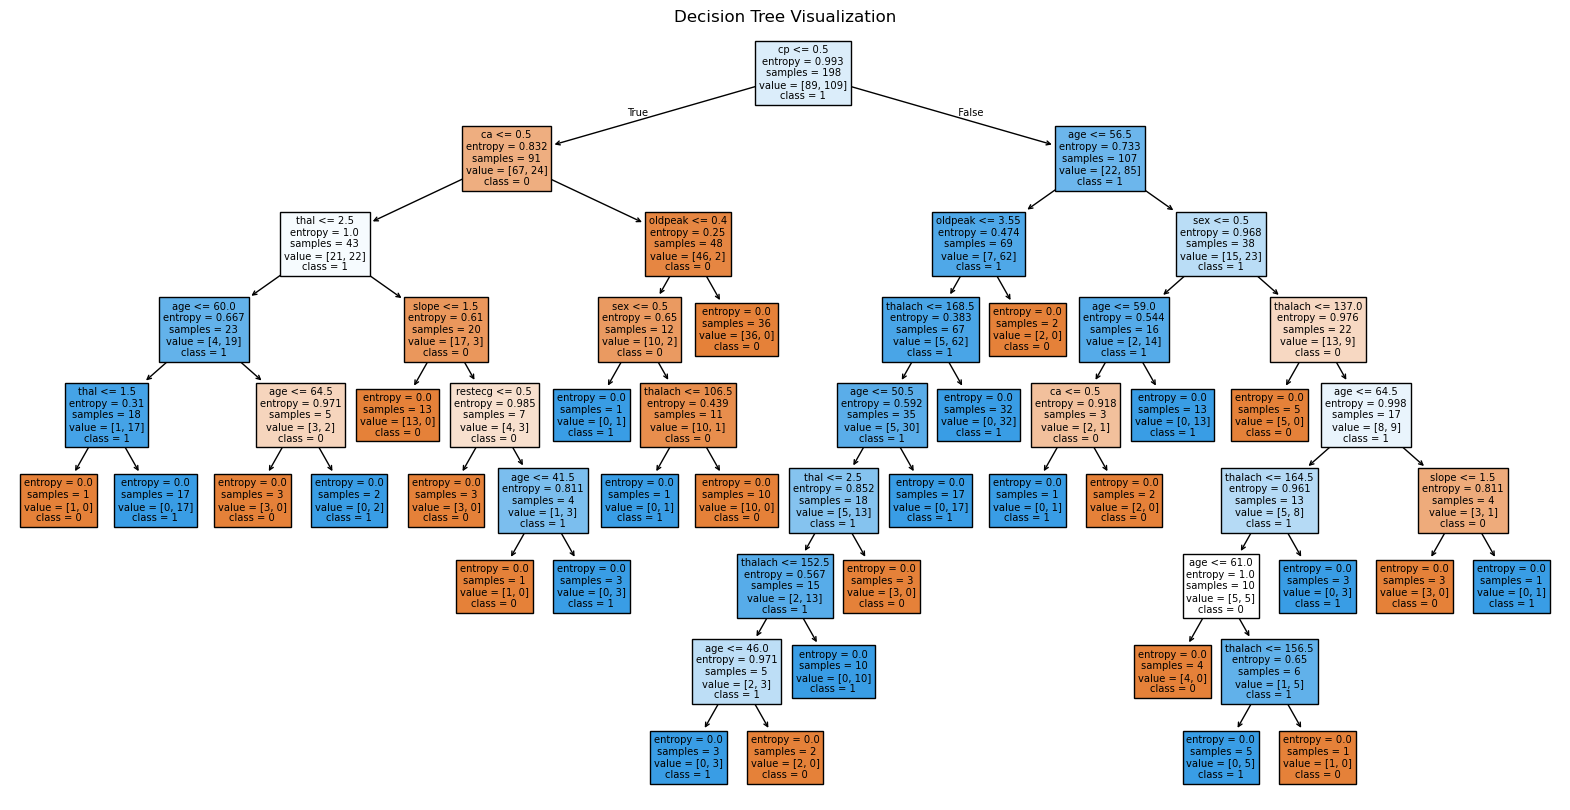

In [9]:
# 7. Train a basic Decision Tree

clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'Basic Decision Tree Accuracy: {accuracy:.2f}')

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Experiment with different tree depths

depths = [2, 3, 4, 5, None]
accuracies = []

print("\nAccuracy for different tree depths:")
for depth in depths:
    clf_depth = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf_depth.fit(X_train, y_train)
    y_pred_depth = clf_depth.predict(X_test)
    acc = accuracy_score(y_test, y_pred_depth)
    accuracies.append(acc)
    print(f"Depth: {depth}, Accuracy: {acc:.2f}")

# 9. Plot accuracies vs tree depths

plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in depths], accuracies, marker='o')
plt.title('Decision Tree Accuracy vs. Depth')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

# 11. Visualize the best decision tree

plt.figure(figsize=(20, 10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['0', '1'], filled=True)
plt.title('Decision Tree Visualization')
plt.show()

   Feature  Information Gain
0      age          0.231310
2       cp          0.215563
9     thal          0.141816
4  thalach          0.123833
8       ca          0.119668
6  oldpeak          0.057049
1      sex          0.048704
7    slope          0.043479
3  restecg          0.018579
5    exang          0.000000


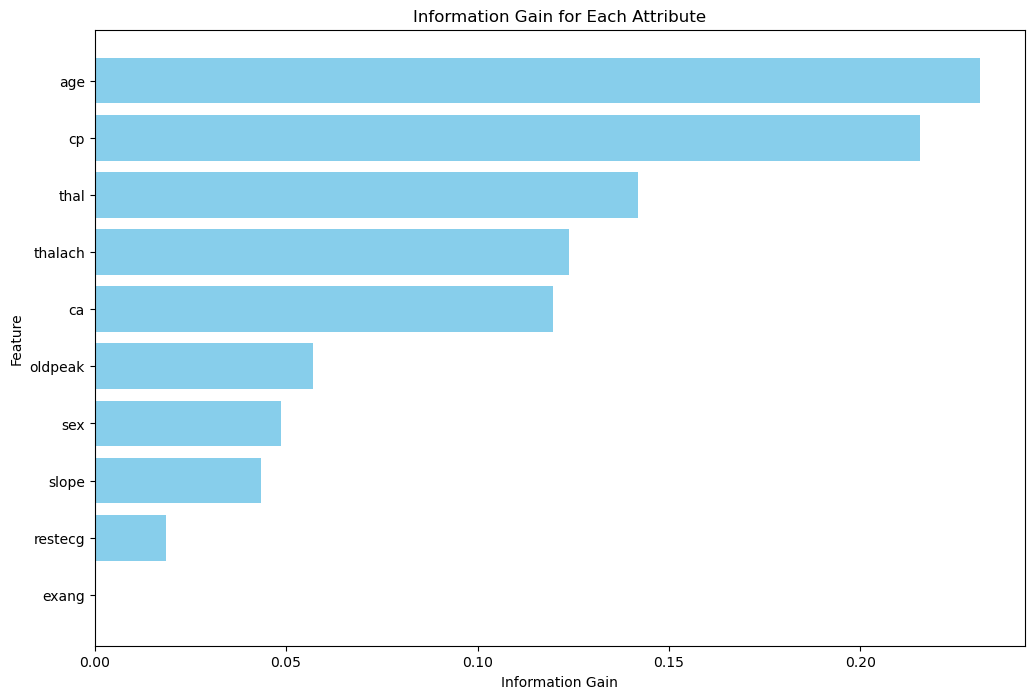

In [12]:
# Extract feature importances (Information Gain) from the model
information_gain = clf.feature_importances_

# Create a DataFrame to display feature names and their Information Gain
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': information_gain
}).sort_values(by='Information Gain', ascending=False)

# Display the DataFrame
print(feature_importance_df)

# Plot the Information Gain for each feature
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Information Gain'], color='skyblue')
plt.xlabel('Information Gain')
plt.ylabel('Feature')
plt.title('Information Gain for Each Attribute')
plt.gca().invert_yaxis()
plt.show()